# Question Generator — Dataset Preparation

**AI Interview Assistant · Agent 02 (Question Generation)**

## 1. Objective

The Question Generator is the agent that asks the candidate the next technical
question, conditioned on a domain and a difficulty level. To fine-tune it
locally with QLoRA/SFT — instead of calling a commercial API — it needs a corpus
of *real* software-engineering interview questions, labelled with the project's
16 interview domains and a Beginner / Intermediate / Advanced difficulty.

Two openly available datasets are used:

| Dataset | What it contributes |
|---|---|
| `ali-alkhars/interviews` | Genuine interview questions, already phrased the way an interviewer speaks. This is the **style** target. It carries no answers. |
| `common-pile/stackexchange` | CC-BY-SA Stack Exchange dump (Dec 2024). Supplies **breadth** across all 16 domains and the **answers** that become `expected_answer`. |

The processed output is a train / validation / test split of JSONL records that
`train_qlora.py` consumes directly for QLoRA supervised fine-tuning.

> This notebook **does not download anything** and **does not start training**.
> It loads what is already on disk, runs the project's own preprocessing
> functions, and validates the result.

### How to read this notebook

Every number, table and chart below is computed from the data at execution time.
Nothing is typed in by hand. The notebook imports
`dataset/prepare_question_generator.py` and `dataset/interview_domains.py` — the
same modules the command-line pipeline uses — so there is exactly one
implementation of the preprocessing logic:

```text
        dataset/interview_domains.py        (16 domains, difficulty rules)
        dataset/prepare_question_generator.py  (filter / clean / map / dedup / split)
                          ▲
                          │  imports
                          │
        this notebook  ───┘   demonstrates and analyses
```

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# The notebook lives in ml-service/notebooks/; the pipeline lives in ml-service/dataset/.
ML_SERVICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_SERVICE / "dataset"))

import interview_domains as domains
import prepare_question_generator as prep

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("ml-service :", ML_SERVICE)
print("raw dir    :", prep.RAW)
print("output dir :", prep.PROCESSED)
print("domains    :", len(domains.DOMAIN_NAMES))

ml-service : C:\Users\gihan\Documents\ai-interview-system\ml-service
raw dir    : C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\raw
output dir : C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator
domains    : 16


## 2. Dataset sources

Both datasets were fetched earlier by `dataset/download_datasets.py`. Nothing is
re-downloaded here — the cell below only inspects what is on disk.

`common-pile/stackexchange` is a 103.7 GB / 33.4 M-document dump of 350+ Stack
Exchange sites. Fetching it whole is neither affordable nor useful, so
`download_datasets.py` scopes the fetch to eight sites via an allow-list
(`SE_SITES`) and records the resulting shard paths in a small manifest. The
shards stay in the HuggingFace hub cache and are streamed from there — they are
never copied into the repository, so they exist exactly once on disk.

In [2]:
import download_datasets as dl

manifest = json.loads(prep.SE_MANIFEST.read_text(encoding="utf-8"))

rows = []
for site, shards in manifest["sites"].items():
    size = sum(Path(s).stat().st_size for s in shards)
    rows.append({"site": site,
                 "shards": len(shards),
                 "size_MB": round(size / 1e6, 1),
                 "domains it feeds": ", ".join(domains.SITE_DOMAIN_PRIOR[site])})

se_sites = pd.DataFrame(rows)
print(f"common-pile/stackexchange — {len(se_sites)} of 350+ sites kept, "
      f"{se_sites.shards.sum()} shards, {se_sites.size_MB.sum():.0f} MB on disk")
print(f"snapshot: {manifest['snapshot_path']}")
se_sites

common-pile/stackexchange — 8 of 350+ sites kept, 15 shards, 702 MB on disk
snapshot: C:\Users\gihan\.cache\huggingface\hub\datasets--common-pile--stackexchange\snapshots\5ec3aa2e65b7c61b7c18f1ff18ccbc4d3279a23c


,site,shards,size_MB,domains it feeds
0,softwareengineering.stackexchange.com,2,151.7,"OOP, Design Patterns, System Design, Microservices, REST APIs, Programming Languages"
1,codereview.stackexchange.com,2,210.6,"OOP, Programming Languages, Design Patterns, Unit Testing"
2,cs.stackexchange.com,2,56.9,"Algorithms, Data Structures, Concurrency"
3,cstheory.stackexchange.com,2,19.0,"Algorithms, Data Structures"
4,dba.stackexchange.com,2,132.8,"SQL, Database Optimization"
5,devops.stackexchange.com,2,6.6,"Docker, Kubernetes, Microservices, System Design"
6,security.stackexchange.com,1,109.8,Security
7,sqa.stackexchange.com,2,14.8,Unit Testing


In [3]:
interviews_size = sum(f.stat().st_size for f in prep.INTERVIEWS_DIR.rglob("*") if f.is_file())
print(f"ali-alkhars/interviews  -> {prep.INTERVIEWS_DIR}")
print(f"                           {interviews_size/1e3:.0f} KB, HF save_to_disk format")
print()
print("Excluded on purpose: stackoverflow.com is 27 GB on its own and is dominated by")
print("'my code throws X' posts that fail the interview-quality filter anyway.")

ali-alkhars/interviews  -> C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\raw\ali-alkhars__interviews
                           249 KB, HF save_to_disk format

Excluded on purpose: stackoverflow.com is 27 GB on its own and is dominated by
'my code throws X' posts that fail the interview-quality filter anyway.


## 3. Load raw data

### 3.1 `ali-alkhars/interviews`

An HF `DatasetDict` with a single `train` split and two string columns:

* `input` — the user prompt that would elicit the question
  (*"I need Vue interview questions"*)
* `response` — the interview question itself

The `input` column is useful beyond provenance: it names the topic outright, so
it acts as a high-confidence prior during domain mapping.

In [4]:
from datasets import load_from_disk

interviews_ds = load_from_disk(str(prep.INTERVIEWS_DIR))
print(interviews_ds)

pd.DataFrame(interviews_ds["train"][:6])

C:\Users\gihan\Documents\ai-interview-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['input', 'response'],
        num_rows: 2292
    })
})


,input,response
0,General interview question,Why should we hire you?
1,General interview question,Tell me about yourself.
2,Can you give me interview questions about Angular?,What is Angular Framework?
3,Could we do a mock interview?,What is the difference between AngularJS and Angular?
4,Could we do a mock interview?,What is TypeScript?
5,Prepare me for an interview for a software engineering role,Write a pictorial diagram of Angular architecture?


### 3.2 `common-pile/stackexchange`

Each line of a shard is one **whole thread** flattened into a single `text`
field. There are **no tags and no scores** — a structural difference from the
older Stack Exchange dumps that the project's `DATASETS.md` recipe assumed. The
layout, per the dataset card, is:

```text
line 1                    question title
following lines           question body
blank line, then blocks   comments, then answers ordered by votes
```

`prep._split_se_document()` recovers `(title, body, best_answer)` from that blob.

In [5]:
raw_se_sample = []
for rec in prep.load_stackexchange(limit_per_shard=400):
    raw_se_sample.append(rec)
print(f"loaded {len(raw_se_sample):,} raw Stack Exchange documents for demonstration")
print("(the full pipeline in section 12 streams all", "397,632 documents)")
print()
print("fields recovered per document:", list(raw_se_sample[0].keys()))

2026-08-22 19:46:51,767 INFO reading softwareengineering.stackexchange.com/00000_se.jsonl.gz


2026-08-22 19:46:51,938 INFO reading softwareengineering.stackexchange.com/00001_se.jsonl.gz


2026-08-22 19:46:52,105 INFO reading codereview.stackexchange.com/00000_se.jsonl.gz


2026-08-22 19:46:52,234 INFO reading codereview.stackexchange.com/00001_se.jsonl.gz


2026-08-22 19:46:52,400 INFO reading cs.stackexchange.com/00000_se.jsonl.gz


...

2026-08-22 19:46:53,218 INFO reading devops.stackexchange.com/00001_se.jsonl.gz


2026-08-22 19:46:53,308 INFO reading security.stackexchange.com/00000_se.jsonl.gz


2026-08-22 19:46:53,549 INFO reading sqa.stackexchange.com/00000_se.jsonl.gz


2026-08-22 19:46:53,730 INFO reading sqa.stackexchange.com/00001_se.jsonl.gz


loaded 5,906 raw Stack Exchange documents for demonstration
(the full pipeline in section 12 streams all 397,632 documents)

fields recovered per document: ['raw_id', 'site', 'prompt', 'title', 'body', 'answer', 'url', 'license', 'source']


In [6]:
example = next(r for r in raw_se_sample if r["site"] == "dba.stackexchange.com" and r["answer"])
print("TITLE  :", example["title"])
print("SITE   :", example["site"], "|", example["url"])
print()
print("BODY   :", example["body"][:400].replace("\n", " "), "...")
print()
print("ANSWER :", example["answer"][:400].replace("\n", " "), "...")

TITLE  : Which collation should I choose for a muiti-language website?
SITE   : dba.stackexchange.com | https://dba.stackexchange.com/questions/255

BODY   : Does a collation have any influence over a query speed? Does the size of a table change depending of the collation? If I want to build a website that must support all possible languages (lets take for e.g. Google) which would be the recommended collation? I will need to store characters such as 日本語, my searches over the website will have to return something for the sóméthíng input, it must be case ...

ANSWER : locale.strxfrm is a function which Returns a string that behaves for cmp locale-aware, that is, it encodes a string such that a byte-by-byte standard lexicographic comparison against another string encoded similarly will produce the same result as comparing strings according to the collation function specified by the locale. Some observations: in da_DK.utf8, the string ouüö is sorted.  In de_DE.ut ...


## 4. Initial data analysis

Before any filtering: how much is there, how much of it is empty or duplicated,
and how long are the questions?

In [7]:
raw_interviews = prep.load_interviews()

def raw_overview(records, name):
    titles = [r["title"] or "" for r in records]
    return {
        "source": name,
        "records": len(records),
        "empty question": sum(1 for t in titles if not t.strip()),
        "missing answer": sum(1 for r in records if not (r["answer"] or "").strip()),
        "exact duplicate questions": len(titles) - len({t.strip().lower() for t in titles}),
        "min chars": min(len(t) for t in titles),
        "mean chars": round(sum(len(t) for t in titles) / len(titles), 1),
        "max chars": max(len(t) for t in titles),
    }

overview = pd.DataFrame([
    raw_overview(raw_interviews, "ali-alkhars/interviews (full)"),
    raw_overview(raw_se_sample, "common-pile/stackexchange (sample)"),
]).set_index("source")
overview.T

source,ali-alkhars/interviews (full),common-pile/stackexchange (sample)
records,2292.0,5906.0
empty question,1.0,0.0
missing answer,2292.0,1808.0
exact duplicate questions,55.0,2.0
min chars,0.0,15.0
mean chars,57.4,54.9
max chars,630.0,150.0


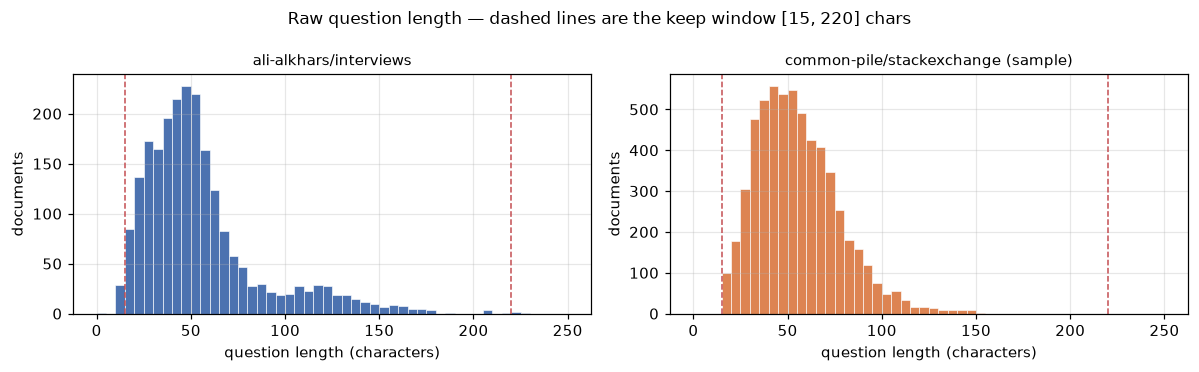

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (recs, name, colour) in zip(axes, [
        (raw_interviews, "ali-alkhars/interviews", "#4C72B0"),
        (raw_se_sample, "common-pile/stackexchange (sample)", "#DD8452")]):
    lengths = [len(r["title"] or "") for r in recs]
    ax.hist(lengths, bins=50, range=(0, 250), color=colour, edgecolor="white", linewidth=0.4)
    ax.axvline(prep.MIN_QUESTION_CHARS, color="#C44E52", ls="--", lw=1)
    ax.axvline(prep.MAX_QUESTION_CHARS, color="#C44E52", ls="--", lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("question length (characters)")
    ax.set_ylabel("documents")
fig.suptitle("Raw question length — dashed lines are the keep window "
             f"[{prep.MIN_QUESTION_CHARS}, {prep.MAX_QUESTION_CHARS}] chars", fontsize=11)
fig.tight_layout()
plt.show()

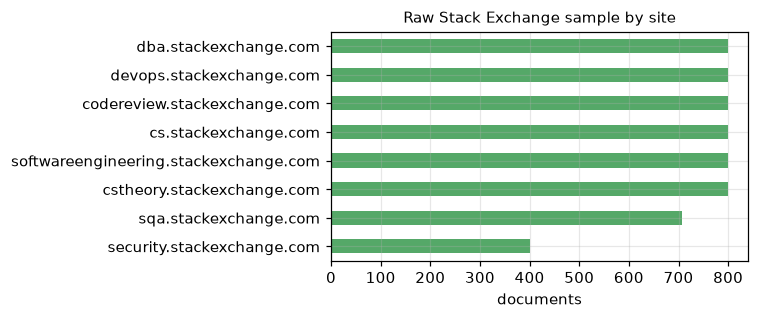

In [9]:
site_counts = Counter(r["site"] for r in raw_se_sample)
ax = pd.Series(site_counts).sort_values().plot.barh(figsize=(7, 3), color="#55A868")
ax.set_title("Raw Stack Exchange sample by site", fontsize=10)
ax.set_xlabel("documents")
plt.tight_layout()
plt.show()

Neither source arrives with a `domain` label — `ali-alkhars/interviews` only
hints at the topic in its prompt text, and `common-pile/stackexchange` dropped
the tag field entirely. Domain assignment therefore has to be derived
(section 7).

## 5. Stack Exchange filtering

```text
        Raw StackExchange  (33.4 M documents, 103.7 GB, 350+ sites)
                    │
                    │  (a) site allow-list, applied at download time
                    ▼
        8 interview-relevant sites  (397,632 documents, 660 MB)
                    │
                    │  (b) interview-quality filters, per document
                    ▼
        Questions that read like interview questions
                    │
                    │  (c) keyword scoring against the 16 domains
                    ▼
        Relevant StackExchange questions, domain-labelled
                    │
                    │  (d) per-domain and per-source caps
                    ▼
        Balanced contribution to the training set
```

Step (a) was shown in section 2. Steps (b) and (c) are demonstrated below on the
sample; the counts for the **full** run appear in section 12.

The quality filters exist because a Stack Exchange title is not automatically an
interview question. `"Deadlock in REDO thread, 1 replica went OK?"` ends in a
question mark but is a bug report, so ending in `?` is not sufficient — the
title must *open* with an interrogative.

In [10]:
filter_stats = Counter()
kept_sample = []
for raw in raw_se_sample:
    rec = prep.build_record(raw, filter_stats)
    if rec:
        kept_sample.append(rec)

drops = {k.split(".")[-1]: v for k, v in filter_stats.items() if k.startswith("drop.")}
funnel = pd.DataFrame(
    [{"stage": "raw documents", "removed": 0, "remaining": len(raw_se_sample)}]
    + [{"stage": f"drop: {k}", "removed": v} for k, v in
       sorted(drops.items(), key=lambda kv: -kv[1])])
running = len(raw_se_sample)
remaining = []
for _, row in funnel.iterrows():
    running -= int(row["removed"])
    remaining.append(running)
funnel["remaining"] = remaining
funnel["% of raw"] = (funnel.remaining / len(raw_se_sample) * 100).round(1)
funnel

,stage,removed,remaining,% of raw
0,raw documents,0,5906,100.0
1,drop: not_a_question,3723,2183,37.0
2,drop: off_domain,1325,858,14.5
3,drop: non_interview_content,160,698,11.8
4,drop: too_few_words,55,643,10.9
5,drop: corrupted,3,640,10.8


In [11]:
print(f"before filtering : {len(raw_se_sample):,}")
print(f"removed          : {len(raw_se_sample) - len(kept_sample):,}")
print(f"remaining        : {len(kept_sample):,} "
      f"({100*len(kept_sample)/len(raw_se_sample):.1f}%)")
print()
print("Records per domain in the filtered sample:")
per_domain = Counter(r["domain"] for r in kept_sample)
pd.Series({d: per_domain.get(d, 0) for d in domains.DOMAIN_NAMES},
          name="records").to_frame()

before filtering : 5,906
removed          : 5,266
remaining        : 640 (10.8%)

Records per domain in the filtered sample:


,records
SQL,199
Database Optimization,25
OOP,13
Design Patterns,19
Microservices,8
Docker,48
Kubernetes,37
REST APIs,3
Concurrency,6
Algorithms,57


The rejection reasons are worth reading rather than skipping: `not_a_question`
removes the overwhelming majority. That is expected — `codereview.stackexchange`
titles are noun phrases describing code ("Tic-tac-toe game in Python"), not
questions, and they are correctly discarded. Below are examples of what each
filter throws away, so the filtering can be audited rather than trusted.

In [12]:
rejected = {}
for raw in raw_se_sample:
    q = prep.normalise_question(raw["title"])
    reason = prep.question_reject_reason(q)
    if reason:
        rejected.setdefault(reason, []).append(q[:95])

for reason, examples in sorted(rejected.items(), key=lambda kv: -len(kv[1])):
    print(f"--- {reason}  ({len(examples)} in sample)")
    for e in examples[:3]:
        print("    ", e)

--- not_a_question  (3723 in sample)
     Running time of simple for-loops
     Windows GUIs: How Long Will 'Deprecated' APIs Last?
     Skeptic in a Scrum Team
--- non_interview_content  (160 in sample)
     Does open source licensing my code limit me later?
     Should I provide some way to disable my software post-delivery?
     How to include an apache library with my opensource code?
--- too_few_words  (55 in sample)
     HTML/CSS plagiarism
     Simple TimeZones
     Define "production-ready"
--- corrupted  (3 in sample)
     Why is $3^{\log2 n}$ the same as $n^{\log2 3}$?
     Is $\ L = \{ \ w \in \{a, b, c\}^ \ | \ w = uv \ \ and \ \ \#a(u) + \#b(u) = \#b(v) + \#c(v) \ 
     Why does (y 0 ^ y < 10)?


## 6. Data cleaning

`prep.clean_text()` is deliberately conservative. It removes markup and
boilerplate but never rewrites words, so technical terminology and the original
meaning survive intact:

| Step | What it does |
|---|---|
| fenced code blocks | removed (``` … ```) |
| Markdown links | reduced to their visible text |
| bare URLs | removed |
| HTML tags | stripped |
| HTML entities | decoded (`&amp;` → `&`) |
| headings, block quotes, emphasis | markers removed |
| whitespace | CRLF normalised, runs of spaces collapsed, 3+ blank lines → 2, every line trimmed |

In [13]:
messy = next(r for r in raw_se_sample
             if "<" in r["body"] or "](" in r["body"] or "http" in r["body"])
before = messy["body"][:420]
after = prep.clean_text(messy["body"])[:420]
print("BEFORE\n" + "-" * 70)
print(before)
print()
print("AFTER\n" + "-" * 70)
print(after)

BEFORE
----------------------------------------------------------------------
I'm reading algorithms and I understand most of it, one thing that I can still struggle with a lot is something as simple as running times on different for-loops. Everyone seems to have easy with that, except for me and therefore I search help here.
I am currently doing some excercises from my book and I need help completing them in order to figure out the different running times.
The title of the exercise is: "Give 

AFTER
----------------------------------------------------------------------
I'm reading algorithms and I understand most of it, one thing that I can still struggle with a lot is something as simple as running times on different for-loops. Everyone seems to have easy with that, except for me and therefore I search help here.
I am currently doing some excercises from my book and I need help completing them in order to figure out the different running times.
The title of the exercise is: "Give 


In [14]:
# Per-step removal counts over the demonstration sample.
steps = []
n = len(raw_se_sample)
titles = [r["title"] or "" for r in raw_se_sample]

stage_counts = [("raw titles", n)]
kept = [t for t in titles if t.strip()]
stage_counts.append(("non-empty", len(kept)))
kept = [prep.normalise_question(t) for t in kept]
kept = [t for t in kept if t]
stage_counts.append(("cleaned + whitespace-normalised", len(kept)))
kept = [t for t in kept if len(t) >= prep.MIN_QUESTION_CHARS]
stage_counts.append((f"length >= {prep.MIN_QUESTION_CHARS} chars", len(kept)))
kept = [t for t in kept if len(t) <= prep.MAX_QUESTION_CHARS]
stage_counts.append((f"length <= {prep.MAX_QUESTION_CHARS} chars", len(kept)))
kept = [t for t in kept if prep.question_reject_reason(t) is None]
stage_counts.append(("interview-quality filters", len(kept)))
seen, deduped = set(), []
for t in kept:
    k = prep.exact_key(t)
    if k not in seen:
        seen.add(k)
        deduped.append(t)
stage_counts.append(("exact deduplication", len(deduped)))

cleaning = pd.DataFrame(stage_counts, columns=["step", "after"])
cleaning["before"] = cleaning["after"].shift(1).fillna(n).astype(int)
cleaning["removed"] = cleaning["before"] - cleaning["after"]
cleaning[["step", "before", "after", "removed"]]

,step,before,after,removed
0,raw titles,5906,5906,0
1,non-empty,5906,5906,0
2,cleaned + whitespace-normalised,5906,5906,0
3,length >= 15 chars,5906,5906,0
4,length <= 220 chars,5906,5906,0
5,interview-quality filters,5906,1965,3941
6,exact deduplication,1965,1965,0


## 7. Domain mapping

### The 16 domains

The project referred to "the 16-category JSON schema" in `DATASETS.md` but never
enumerated the list. `dataset/interview_domains.py` is that enumeration, and it
invents nothing:

* **1–14** are the Stack Exchange filter tags already written down in
  `DATASETS.md` §A.
* **15–16** are the two remaining dataset categories from
  `AI_Interview_Assistant_Research_Plan.md` §6.1 — *Frontend* (React, Angular,
  state management) and *Programming* (Java, Python, PHP, JavaScript).

### How a record is mapped

```text
score(domain) = 3.0 x (strong terms present) + 1.0 x (weak terms present) + prior
```

The prior is a bonus for the domains a source leans towards — the Stack Exchange
site (`dba.stackexchange.com` → SQL / Database Optimization, weight 1.0) or, for
`ali-alkhars/interviews`, the source prompt, which names the topic outright
(*"I need Vue interview questions"* → Frontend Development, weight 3.0). The
prior never overrides keywords, so a Kubernetes question asked on
`dba.stackexchange.com` still maps to Kubernetes. Records whose best score stays
below `MIN_DOMAIN_SCORE` are dropped as off-domain. Ties break on the fixed
domain order, so the mapping is fully reproducible.

In [15]:
taxonomy = pd.DataFrame([
    {"#": i + 1, "domain": name, "slug": slug,
     "strong terms": len(domains.DOMAIN_KEYWORDS[name]["strong"]),
     "weak terms": len(domains.DOMAIN_KEYWORDS[name]["weak"])}
    for i, (name, slug) in enumerate(domains.DOMAINS.items())
]).set_index("#")
print(f"MIN_DOMAIN_SCORE = {domains.MIN_DOMAIN_SCORE}  "
      f"(strong={domains.STRONG_WEIGHT}, weak={domains.WEAK_WEIGHT}, "
      f"site prior={domains.PRIOR_WEIGHT}, prompt prior={domains.PROMPT_PRIOR_WEIGHT})")
taxonomy

MIN_DOMAIN_SCORE = 3.0  (strong=3.0, weak=1.0, site prior=1.0, prompt prior=3.0)


,domain,slug,strong terms,weak terms
#,,,,
1,SQL,sql,17,17
2,Database Optimization,database-optimization,15,9
3,OOP,oop,14,9
4,Design Patterns,design-patterns,17,7
5,Microservices,microservices,12,10
6,Docker,docker,13,5
7,Kubernetes,kubernetes,13,8
8,REST APIs,rest,14,10
9,Concurrency,concurrency,16,11


In [16]:
for q, priors in [
        ("Explain the difference between INNER JOIN and LEFT JOIN", []),
        ("How do you roll back a failed Kubernetes deployment?", domains.site_priors("dba.stackexchange.com")),
        ("How do you watch route object changes?", domains.prompt_priors("I need Vue interview questions")),
        ("What is the weather like today?", [])]:
    weight = domains.PROMPT_PRIOR_WEIGHT if priors else domains.PRIOR_WEIGHT
    domain, score = domains.classify_domain(q, priors, weight)
    print(f"{str(domain):24} score={score:5.1f}   {q}")

SQL                      score=  6.0   Explain the difference between INNER JOIN and LEFT JOIN
SQL                      score=  3.0   How do you roll back a failed Kubernetes deployment?
Frontend Development     score=  3.0   How do you watch route object changes?
None                     score=  0.0   What is the weather like today?


## 8. Difficulty classification

Deterministic — no sampling, no model call, the same input always produces the
same label. Difficulty is the sum of two axes:

**Question form** — what the candidate is asked to *do* (Bloom-style):

| Level | Form | Openers |
|---|---|---|
| 1 | recall / definition | `what is`, `define`, `difference between`, `describe` |
| 2 | apply / implement / troubleshoot | `how do i`, `implement`, `configure`, `best way to` |
| 3 | analyse / design / optimise | `design`, `architect`, `trade-off`, `pros and cons`, `optimi`, `why does` |

**Concept depth** — how advanced the subject is:

| Level | Vocabulary | Examples |
|---|---|---|
| 1 | introductory | variable, loop, array, primary key, JSON, unit test |
| 2 | everyday professional | anything not in the other two lists |
| 3 | senior | CAP theorem, MVCC, sharding, lock-free, garbage collection, virtual DOM, CSRF |

`score = form + depth`, then `+0.5` per extra senior term in the question (max
`+1.0`), `+0.5` when the body carries ≥3 senior terms, another `+0.5` at ≥6, and
`+0.5` for questions over 120 characters. Finally:

```text
score <= 3.0   ->  Beginner
score >= 5.0   ->  Advanced
otherwise      ->  Intermediate
```

This maps directly onto the brief: basic definitions → Beginner, practical
implementation and troubleshooting → Intermediate, architecture, optimisation,
trade-offs and complex algorithms → Advanced.

In [17]:
probe = [
    "What is a template?",
    "What are the key components of Angular?",
    "How do I configure a multi-stage Dockerfile?",
    "How do you roll back a failed deployment?",
    "What is eventual consistency?",
    "How would you design a system to handle 1M concurrent users?",
    "What are the trade-offs of sharding a write-heavy table?",
]
pd.DataFrame([{"question": q,
               "score": domains.difficulty_score(q),
               "difficulty": domains.classify_difficulty(q)} for q in probe])

,question,score,difficulty
0,What is a template?,2.0,Beginner
1,What are the key components of Angular?,2.0,Beginner
2,How do I configure a multi-stage Dockerfile?,4.0,Intermediate
3,How do you roll back a failed deployment?,4.0,Intermediate
4,What is eventual consistency?,5.0,Advanced
5,How would you design a system to handle 1M concurrent users?,6.5,Advanced
6,What are the trade-offs of sharding a write-heavy table?,7.0,Advanced


## 9. `expected_answer`

`common-pile/stackexchange` flattens the whole thread into one text field with
no labels, so the answer has to be recovered structurally: split on blank lines,
discard the first block (title + question body), then take the **longest
remaining block** subject to three conditions —

1. at least `MIN_ANSWER_CHARS` characters — a Stack Exchange comment is capped at
   600, so length is what separates answers from comments,
2. it does not end in `?`, which would make it a follow-up question,
3. `prep.is_prose()` — under 40 % code-looking lines and at least 75 %
   letters/whitespace, so pasted source files are rejected.

The chosen block is cleaned and cut at a **sentence boundary** at
`MAX_ANSWER_CHARS`. Every word is the original author's — nothing is generated,
paraphrased or invented.

`ali-alkhars/interviews` has no answers at all, so those records get
`expected_answer: ""` and `expected_answer_source: "none"`. They are kept rather
than discarded because the generator's training target is the *question*;
`expected_answer` is auxiliary metadata for the Answer Evaluation agent. The
validator accepts an empty `expected_answer` only when the source is marked
`"none"`, and reports the count.

In [18]:
print(f"MIN_ANSWER_CHARS = {prep.MIN_ANSWER_CHARS}   MAX_ANSWER_CHARS = {prep.MAX_ANSWER_CHARS}")
with_answer = [r for r in kept_sample if r["expected_answer"]]
print(f"sample: {len(with_answer)}/{len(kept_sample)} records carry an expected answer")
print()
for r in with_answer[:3]:
    print("=" * 78)
    print(f"DOMAIN     : {r['domain']}   DIFFICULTY: {r['difficulty']}")
    print(f"QUESTION   : {r['question']}")
    print(f"EXPECTED   : {r['expected_answer'][:330]}...")

MIN_ANSWER_CHARS = 400   MAX_ANSWER_CHARS = 1200
sample: 453/640 records carry an expected answer

DOMAIN     : SQL   DIFFICULTY: Beginner
QUESTION   : What is the equivalent of functions and methods in SQL?
EXPECTED   : @Chad: My point was that even if you were able to bind a parameter at query time, the database still has to do the same things as if you used the expression to SELECT something (e.g., SELECT a+boundvalue, b+boundvalue ... or in a WHERE clause (e.g., ... WHERE a = boundvalue). Whether you're using plain, indexed or materialized v...
DOMAIN     : Programming Languages   DIFFICULTY: Beginner
QUESTION   : Is functional programming strongly related to mathematics?
EXPECTED   : All programming is related to mathematics. Indeed many universities still place their computer science programs under the purview of the mathematics department.
As for learning functional programming, you do not need to have a strong base in mathematics to learn it. I've learnt three different functio

## 10. Final dataset schema

The four fields the project's interview schema requires are `question`,
`domain`, `difficulty` and `expected_answer`. The pipeline emits those plus
provenance and the instruction-tuning view of the *same* record, so the dataset
is stored once rather than twice.

In [19]:
schema = {
    "question": "the interview question, whitespace-normalised, always ends in '?'",
    "domain": "one of the 16 domains in interview_domains.DOMAINS",
    "difficulty": "Beginner | Intermediate | Advanced",
    "expected_answer": "condensed top answer, or '' when none can be derived",
    "expected_answer_source": "stackexchange_top_answer | none",
    "id": "stable record id, used for deterministic sorting",
    "source": "ali-alkhars/interviews | common-pile/stackexchange",
    "source_url": "provenance, required by the CC-BY-SA attribution clause",
    "license": "per-document licence string from the source",
    "domain_score": "keyword score behind the domain assignment",
    "instruction": "SFT: the task given to the model",
    "input": "SFT: 'Domain: <domain>\\nDifficulty: <difficulty>'",
    "output": "SFT: the target question the model must generate",
}
pd.Series(schema, name="meaning").to_frame()

,meaning
question,"the interview question, whitespace-normalised, always ends in '?'"
domain,one of the 16 domains in interview_domains.DOMAINS
difficulty,Beginner | Intermediate | Advanced
expected_answer,"condensed top answer, or '' when none can be derived"
expected_answer_source,stackexchange_top_answer | none
id,"stable record id, used for deterministic sorting"
source,ali-alkhars/interviews | common-pile/stackexchange
source_url,"provenance, required by the CC-BY-SA attribution clause"
license,per-document licence string from the source
domain_score,keyword score behind the domain assignment


## 11. Run the full pipeline

Everything above operated on a small demonstration sample so the notebook stays
readable. The cell below runs the **real** pipeline — a single streaming pass
over all 397,632 Stack Exchange documents plus the 2,292 interview records —
through the same functions, and writes the splits to
`dataset/processed/question_generator/`.

Takes roughly 3 minutes. Deterministic: same inputs and same seed give the same
output every time.

In [20]:
statistics = prep.run(seed=42, max_per_domain=1200, se_ratio=6.0)
splits = prep.load_processed()
all_records = [r for rs in splits.values() for r in rs]
print()
print(f"total records: {len(all_records):,}")

2026-08-22 19:46:57,441 INFO loading ali-alkhars/interviews


2026-08-22 19:46:58,038 INFO interviews: 2292 raw -> 1215 kept


2026-08-22 19:46:58,039 INFO streaming common-pile/stackexchange (site-scoped)


2026-08-22 19:46:58,041 INFO reading softwareengineering.stackexchange.com/00000_se.jsonl.gz


2026-08-22 19:47:48,626 INFO reading softwareengineering.stackexchange.com/00001_se.jsonl.gz


...

2026-08-22 19:50:49,326 INFO dedup: 45361 -> 45205 (136 exact, 20 near)


2026-08-22 19:50:49,482 INFO balance: 45205 -> 8330


2026-08-22 19:50:49,499 INFO split: train=6625 validation=825 test=880


2026-08-22 19:50:50,397 INFO wrote C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator



total records: 8,330


## 12. Filtering report (full run)

Nothing is discarded silently. Every drop is counted, tagged with its source and
its reason, and written to `statistics.json`.

In [21]:
f = statistics["filtering"]
drop_rows = []
for key, value in sorted(f.items()):
    if key.startswith("drop."):
        _, src, reason = key.split(".", 2)
        drop_rows.append({"source": src, "reason": reason, "dropped": value})
drops_df = (pd.DataFrame(drop_rows)
            .pivot(index="reason", columns="source", values="dropped")
            .fillna(0).astype(int))
drops_df["total"] = drops_df.sum(axis=1)
drops_df.sort_values("total", ascending=False)

source,interviews,stackexchange,total
reason,,,
not_a_question,338,266168,266506
off_domain,656,71742,72398
non_interview_content,30,12046,12076
too_few_words,2,3346,3348
corrupted,0,170,170
too_short,29,14,43
too_long,21,0,21
empty,1,0,1


In [22]:
summary = pd.DataFrame([
    {"source": "ali-alkhars/interviews",
     "raw": f["raw_interviews"], "kept after filtering": f["kept_interviews"]},
    {"source": "common-pile/stackexchange",
     "raw": f["raw_stackexchange"], "kept after filtering": f["kept_stackexchange"]},
]).set_index("source")
summary["kept %"] = (100 * summary["kept after filtering"] / summary["raw"]).round(1)
print(summary.to_string())
print()

caps = {k.replace("cap_domain_", ""): v for k, v in f.items() if k.startswith("cap_domain_")}
print("Balancing — Stack Exchange records dropped by the per-domain cap "
      f"(max {statistics['config']['max_per_domain']} per domain):")
for d, v in sorted(caps.items(), key=lambda kv: -kv[1]):
    print(f"    {d:24} -{v:,}")
print(f"\nGlobal cap (Stack Exchange <= {statistics['config']['se_ratio']}x interviews): "
      f"-{f.get('cap_se_global', 0):,}")
print("\nNo records were duplicated to inflate a thin domain — under-represented")
print("domains stay small and show up as such in the counts below.")

                              raw  kept after filtering  kept %
source                                                         
ali-alkhars/interviews       2292                  1215    53.0
common-pile/stackexchange  397632                 44146    11.1

Balancing — Stack Exchange records dropped by the per-domain cap (max 1200 per domain):
    SQL                      -17,448
    Security                 -7,100
    Algorithms               -1,414
    Programming Languages    -1,064
    Database Optimization    -732
    Design Patterns          -498
    Data Structures          -490
    OOP                      -420
    Unit Testing             -257

Global cap (Stack Exchange <= 6.0x interviews): -7,452

No records were duplicated to inflate a thin domain — under-represented
domains stay small and show up as such in the counts below.


## 13. Deduplication and data-leakage check

Deduplication runs **before** the split, which makes leakage structurally
impossible. The validator then re-checks it independently rather than assuming
it:

| Stage | Key | When it fires |
|---|---|---|
| Exact | SHA-1 of lowercased, punctuation-free, stopword-stripped tokens | identical wording modulo case/punctuation |
| Near | SHA-1 of the *sorted set* of those tokens | same content words in a different order |
| Leakage sweep | token Jaccard ≥ 0.9 via an inverted index, across every split pair | a near-identical question in two splits |

In [23]:
print(f"Duplicate records found and removed:")
print(f"    exact : {f['dedup_exact']:,}")
print(f"    near  : {f['dedup_near']:,}")
print(f"    total : {f['dedup_exact'] + f['dedup_near']:,}")
print()

errors, warnings, report = prep.validate_splits(splits)
for pair, count in report["leakage"].items():
    print(f"{pair:24} leakage: {count}")
print()
print(f"Exact duplicates remaining in the dataset: {report['exact_duplicates']}")
print(f"Validation errors: {len(errors)}   warnings: {len(warnings)}")
for w in warnings:
    print("   warning:", w)

Duplicate records found and removed:
    exact : 136
    near  : 20
    total : 156



train->validation        leakage: 0
train->test              leakage: 0
validation->test         leakage: 0

Exact duplicates remaining in the dataset: 0
Validation errors: 0   warnings: 0


## 14. Train / validation / test split

80 / 10 / 10, stratified over `(domain, difficulty, source)` so no split loses a
combination, shuffled with `random.Random(42)`. Each stratum is sorted by `id`
before shuffling, so the split is byte-for-byte reproducible.

In [24]:
split_sizes = pd.DataFrame([
    {"split": name, "records": len(rs),
     "share %": round(100 * len(rs) / len(all_records), 1)}
    for name, rs in splits.items()]).set_index("split")
split_sizes

,records,share %
split,,
train,6625,79.5
validation,825,9.9
test,880,10.6


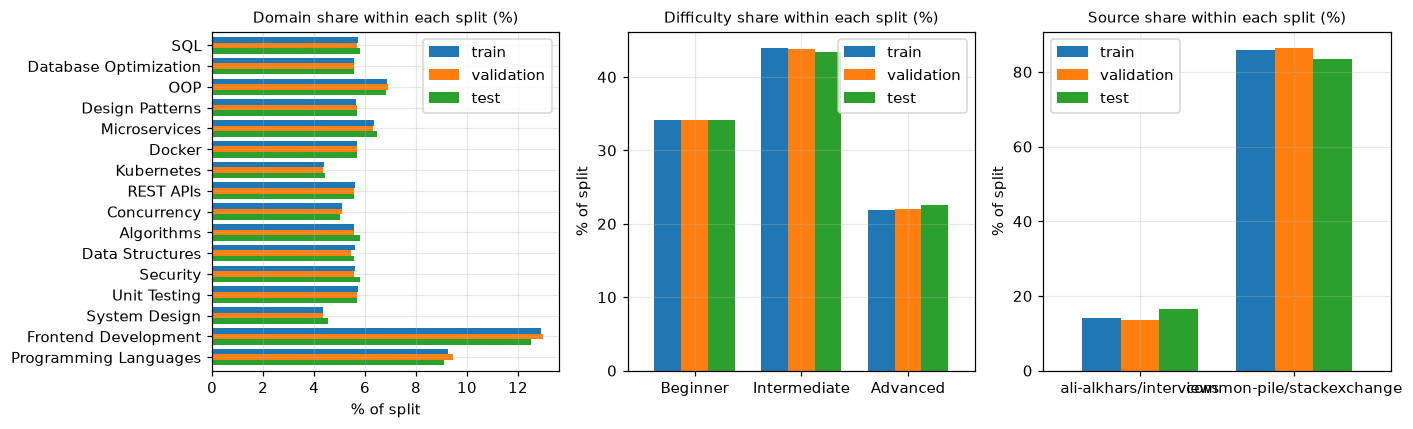

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

dom = pd.DataFrame({name: pd.Series(statistics["domain_by_split"][name])
                    for name in ("train", "validation", "test")}).reindex(domains.DOMAIN_NAMES).fillna(0)
(dom / dom.sum() * 100).plot.barh(ax=axes[0], width=0.8)
axes[0].set_title("Domain share within each split (%)", fontsize=10)
axes[0].set_xlabel("% of split")
axes[0].invert_yaxis()

dif = pd.DataFrame({name: pd.Series(statistics["difficulty_by_split"][name])
                    for name in ("train", "validation", "test")}).reindex(domains.DIFFICULTIES)
(dif / dif.sum() * 100).plot.bar(ax=axes[1], width=0.75, rot=0)
axes[1].set_title("Difficulty share within each split (%)", fontsize=10)
axes[1].set_ylabel("% of split")

src = pd.DataFrame({name: pd.Series(statistics["source_by_split"][name])
                    for name in ("train", "validation", "test")}).fillna(0)
(src / src.sum() * 100).plot.bar(ax=axes[2], width=0.75, rot=0)
axes[2].set_title("Source share within each split (%)", fontsize=10)
axes[2].set_ylabel("% of split")

fig.tight_layout()
plt.show()

The three splits track each other closely on all three axes, which is what
stratification is for — the validation and test sets are representative of the
training distribution rather than accidental slices of it.

## 15. Final dataset statistics

In [26]:
by_domain = pd.DataFrame({
    "total": pd.Series(statistics["domain"]),
    **{name: pd.Series(statistics["domain_by_split"][name])
       for name in ("train", "validation", "test")},
}).reindex(domains.DOMAIN_NAMES).fillna(0).astype(int)
by_domain.loc["TOTAL"] = by_domain.sum()
by_domain

,total,train,validation,test
SQL,478,380,47,51
Database Optimization,465,370,46,49
OOP,571,454,57,60
Design Patterns,471,374,47,50
Microservices,531,422,52,57
Docker,473,376,47,50
Kubernetes,366,291,36,39
REST APIs,466,371,46,49
Concurrency,424,338,42,44
Algorithms,467,370,46,51


In [27]:
by_difficulty = pd.DataFrame({
    "total": pd.Series(statistics["difficulty"]),
    **{name: pd.Series(statistics["difficulty_by_split"][name])
       for name in ("train", "validation", "test")},
}).reindex(domains.DIFFICULTIES).fillna(0).astype(int)
by_difficulty["share %"] = (100 * by_difficulty["total"] / by_difficulty["total"].sum()).round(1)
by_difficulty

,total,train,validation,test,share %
Beginner,2847,2265,282,300,34.2
Intermediate,3655,2912,361,382,43.9
Advanced,1828,1448,182,198,21.9


In [28]:
files = sorted(prep.PROCESSED.glob("*"))
disk = pd.DataFrame([{"file": p.name, "size_MB": round(p.stat().st_size / 1e6, 2)}
                     for p in files]).set_index("file")
disk.loc["TOTAL"] = disk.sum().round(2)

summary_table = pd.Series({
    "Sources": len(statistics["source"]),
    "Total records": statistics["total"],
    "Domains covered": statistics["validation"]["domains_covered"],
    "Beginner": statistics["difficulty"]["Beginner"],
    "Intermediate": statistics["difficulty"]["Intermediate"],
    "Advanced": statistics["difficulty"]["Advanced"],
    "Train": statistics["split"]["train"],
    "Validation": statistics["split"]["validation"],
    "Test": statistics["split"]["test"],
    "With expected_answer": statistics["with_expected_answer"],
    "Question chars (min/mean/max)":
        f"{statistics['question_chars']['min']} / "
        f"{statistics['question_chars']['mean']} / "
        f"{statistics['question_chars']['max']}",
    "Size on disk (MB)": disk.loc["TOTAL", "size_MB"],
}, name="value").to_frame()
print(disk.to_string())
print()
summary_table

                  size_MB
file                     
statistics.json      0.00
test.jsonl           1.13
train.jsonl          8.74
validation.jsonl     1.09
TOTAL               10.96



,value
Sources,2
Total records,8330
Domains covered,16/16
Beginner,2847
Intermediate,3655
Advanced,1828
Train,6625
Validation,825
Test,880
With expected_answer,5975


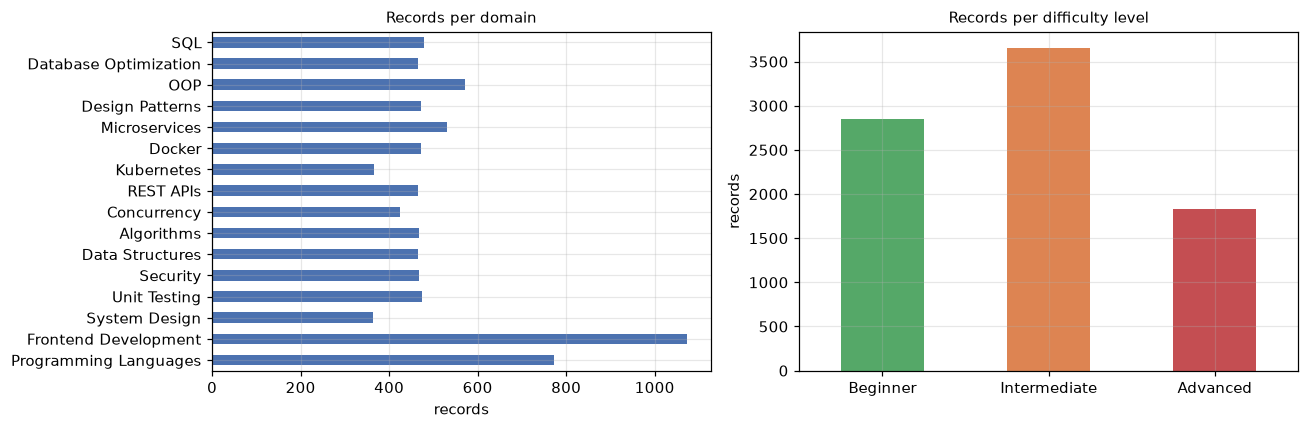

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(statistics["domain"]).reindex(domains.DOMAIN_NAMES).plot.barh(
    ax=axes[0], color="#4C72B0")
axes[0].set_title("Records per domain", fontsize=10)
axes[0].set_xlabel("records")
axes[0].invert_yaxis()

pd.Series(statistics["difficulty"]).reindex(domains.DIFFICULTIES).plot.bar(
    ax=axes[1], color=["#55A868", "#DD8452", "#C44E52"], rot=0)
axes[1].set_title("Records per difficulty level", fontsize=10)
axes[1].set_ylabel("records")

fig.tight_layout()
plt.show()

## 16. Sample final records

Spanning both sources, several domains and all three difficulty levels.

In [30]:
train = splits["train"]
picked, seen = [], set()
for rec in train:
    key = (rec["source"], rec["difficulty"])
    if key in seen:
        continue
    if rec["source"].startswith("common-pile") and not rec["expected_answer"]:
        continue
    seen.add(key)
    picked.append(rec)
    if len(seen) == 6:
        break

for rec in picked:
    print("=" * 90)
    print(f"{rec['domain']}  |  {rec['difficulty']}  |  {rec['source']}")
    print(f"Q: {rec['question']}")
    answer = rec["expected_answer"] or "(none — source carries no answers)"
    print(f"A: {answer[:300]}{'...' if len(answer) > 300 else ''}")

Frontend Development  |  Beginner  |  ali-alkhars/interviews
Q: What is Angular Framework?
A: (none — source carries no answers)
Frontend Development  |  Intermediate  |  ali-alkhars/interviews
Q: How is Dependency Hierarchy formed?
A: (none — source carries no answers)
Frontend Development  |  Advanced  |  ali-alkhars/interviews
Q: What is the role of template compiler for prevention of XSS attacks?
A: (none — source carries no answers)
OOP  |  Beginner  |  common-pile/stackexchange
Q: How Godly does an object need to be before it becomes unholy?
A: According to Wiki "a god object is an object that knows too much or does too much". The general problem I have with this is: What means "too much"? Your question is about searching an absolute statement as we already know we can only find absolute statements within very restricted areas (and that's ...
Design Patterns  |  Intermediate  |  common-pile/stackexchange
Q: How to use inversion of control within a strategy when using the strategy

In [31]:
pd.DataFrame([{k: v for k, v in r.items()
               if k in ("question", "domain", "difficulty", "source")}
              for r in picked])

,question,domain,difficulty,source
0,What is Angular Framework?,Frontend Development,Beginner,ali-alkhars/interviews
1,How is Dependency Hierarchy formed?,Frontend Development,Intermediate,ali-alkhars/interviews
2,What is the role of template compiler for prevention of XSS attacks?,Frontend Development,Advanced,ali-alkhars/interviews
3,How Godly does an object need to be before it becomes unholy?,OOP,Beginner,common-pile/stackexchange
4,How to use inversion of control within a strategy when using the strategy pattern?,Design Patterns,Intermediate,common-pile/stackexchange
5,Are these MySQL Abstraction Classes safe from SQL Injection? Can they be made safe?,SQL,Advanced,common-pile/stackexchange


### The record as the trainer sees it

`train_qlora.py` renders each record into an instruction-tuning prompt. This is
the exact string that reaches the model.

In [32]:
sys.path.insert(0, str(ML_SERVICE))
import train_qlora

print(train_qlora.format_example(picked[0]))

### Instruction:
Generate a technical interview question.

### Input:
Domain: Frontend Development
Difficulty: Beginner

### Response:
What is Angular Framework?


## 17. Reproducibility

There is one implementation of the preprocessing. This notebook imports it; it
does not re-implement it. Every stage above called a function from
`dataset/prepare_question_generator.py` or `dataset/interview_domains.py`, and
section 11 ran the same `prep.run()` entry point the command line uses.

Reproduce the whole thing from a clean shell (with the raw data already present):

```powershell
cd ml-service
python dataset/prepare_question_generator.py                 # build
python dataset/prepare_question_generator.py --validate-only # re-check
```

Determinism comes from: a fixed seed (42), sorting every stratum by `id` before
shuffling, tie-breaking domain classification on a fixed domain order, and
ranking records by an explicit quality key rather than randomly when a cap
applies.

In [33]:
print("Configuration used for this build:")
for k, v in statistics["config"].items():
    print(f"    {k:18} {v}")
print()
print("Functions this notebook called from the pipeline module:")
for fn in ("load_interviews", "load_stackexchange", "clean_text", "normalise_question",
           "question_reject_reason", "is_prose", "condense_answer", "build_record",
           "exact_key", "deduplicate", "balance", "split_records", "validate_splits",
           "build_statistics", "run", "load_processed"):
    print(f"    prep.{fn}")
for fn in ("classify_domain", "classify_difficulty", "difficulty_score",
           "site_priors", "prompt_priors"):
    print(f"    domains.{fn}")

Configuration used for this build:
    seed               42
    max_per_domain     1200
    se_ratio           6.0
    ratios             [0.8, 0.1, 0.1]
    limit_per_shard    None

Functions this notebook called from the pipeline module:
    prep.load_interviews
    prep.load_stackexchange
    prep.clean_text
    prep.normalise_question
    prep.question_reject_reason
    prep.is_prose
    prep.condense_answer
    prep.build_record
    prep.exact_key
    prep.deduplicate
    prep.balance
    prep.split_records
    prep.validate_splits
    prep.build_statistics
    prep.run
    prep.load_processed
    domains.classify_domain
    domains.classify_difficulty
    domains.difficulty_score
    domains.site_priors
    domains.prompt_priors


## 18. Training-readiness check

The same gate `prepare_question_generator.py` runs before it writes anything.

In [34]:
errors, warnings, report = prep.validate_splits(splits)

required = ["question", "domain", "difficulty", "expected_answer",
            "source", "instruction", "input", "output"]

checks = [
    ("Required fields present",
     all(all(k in r for k in required) for r in all_records)),
    ("No empty questions", report["empty_questions"] == 0),
    ("No invalid domains",
     all(r["domain"] in domains.DOMAIN_NAMES for r in all_records)),
    ("No invalid difficulty values",
     all(r["difficulty"] in domains.DIFFICULTIES for r in all_records)),
    ("No exact duplicates", report["exact_duplicates"] == 0),
    ("No train/test leakage", sum(report["leakage"].values()) == 0),
    ("Train/validation/test files created",
     all((prep.PROCESSED / f"{s}.jsonl").exists()
         for s in ("train", "validation", "test"))),
    ("All 16 domains represented",
     report["domains_covered"] == f"{len(domains.DOMAIN_NAMES)}/{len(domains.DOMAIN_NAMES)}"),
    ("All difficulty levels represented in every split",
     all(set(domains.DIFFICULTIES) == {r["difficulty"] for r in rs}
         for rs in splits.values())),
    ("No extremely short or long records",
     report["too_short"] == 0 and report["too_long"] == 0),
    ("Every JSONL line parses",
     all(isinstance(r, dict) for r in all_records)),
]

for label, ok in checks:
    print(f"{'PASS' if ok else 'FAIL'}  {label}")

print()
if all(ok for _, ok in checks) and not errors:
    print("=" * 60)
    print("QUESTION GENERATOR DATASET: READY FOR TRAINING")
    print("=" * 60)
else:
    print("=" * 60)
    print("QUESTION GENERATOR DATASET: NOT READY")
    for label, ok in checks:
        if not ok:
            print("   failed:", label)
    for e in errors:
        print("   error :", e)
    print("=" * 60)

PASS  Required fields present
PASS  No empty questions
PASS  No invalid domains
PASS  No invalid difficulty values
PASS  No exact duplicates
PASS  No train/test leakage
PASS  Train/validation/test files created
PASS  All 16 domains represented
PASS  All difficulty levels represented in every split
PASS  No extremely short or long records
PASS  Every JSONL line parses

QUESTION GENERATOR DATASET: READY FOR TRAINING


## 19. Next step — QLoRA / SFT training

Training is **not** started from this notebook. The dataset is ready; when the
GPU box is available:

```powershell
cd ml-service
pip install -r requirements.txt -r requirements-train.txt
pip install trl bitsandbytes

# sanity check — loads the splits, prints a formatted prompt, stops
python train_qlora.py --dry_run

# the real run
python train_qlora.py --base_model "meta-llama/Meta-Llama-3-8B" `
                      --dataset dataset/processed/question_generator `
                      --output_dir ./models/interview_llm/qlora_question_generator
```

Full method notes and licence obligations:
[`dataset/QUESTION_GENERATOR_DATASET.md`](../dataset/QUESTION_GENERATOR_DATASET.md).